## SCALING:-

- we have two types of scaling

    - Z score (Standardization)

    - Min Max scalar (Normalization)

## Z-SCORE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visa_df=pd.read_csv('Visadataset.csv')

In [3]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [ ]:
# step-1: take the prevailing wage data
# step-2: calculate mean of the data
# step-3: calculate std of the data
# step-4: Nr=data.mean  step1-step2
# step-5: z_wage=Nr/std   step4/step3
# step-6: create a new column visa_df['z_wage']=z_wage

In [4]:
visa_df['prevailing_wage']

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [5]:
mean=np.mean(visa_df['prevailing_wage'])
mean

np.float64(74455.81459209183)

In [6]:
std=np.std(visa_df['prevailing_wage'])
std

52814.90589711402

In [7]:
Nr=visa_df['prevailing_wage']-mean
Nr

0        -73863.611692
1          8969.835408
2         48541.045408
3          8978.215408
4         75451.575408
             ...      
25475      2636.755408
25476    204718.975408
25477     71843.035408
25478     11698.955408
25479     -3578.904592
Name: prevailing_wage, Length: 25480, dtype: float64

In [8]:
z_wage=Nr/std
z_wage

0       -1.398537
1        0.169835
2        0.919079
3        0.169994
4        1.428604
           ...   
25475    0.049924
25476    3.876159
25477    1.360280
25478    0.221509
25479   -0.067763
Name: prevailing_wage, Length: 25480, dtype: float64

In [9]:
visa_df['z_wage']=z_wage
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,z_wage
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,-1.398537
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,0.169835
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,0.919079
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,0.169994
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,1.428604
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified,0.049924
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified,3.876159
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified,1.360280
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified,0.221509


In [10]:
visa_df[['prevailing_wage','z_wage']]

,prevailing_wage,z_wage
0,592.2029,-1.398537
1,83425.6500,0.169835
2,122996.8600,0.919079
3,83434.0300,0.169994
4,149907.3900,1.428604
...,...,...
25475,77092.5700,0.049924
25476,279174.7900,3.876159
25477,146298.8500,1.360280
25478,86154.7700,0.221509


{'whiskers': [<matplotlib.lines.Line2D at 0x1c447500a50>,
 'caps': [<matplotlib.lines.Line2D at 0x1c447500cd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c447500910>],
 'medians': [<matplotlib.lines.Line2D at 0x1c447500f50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1c447501090>],
 'means': []}

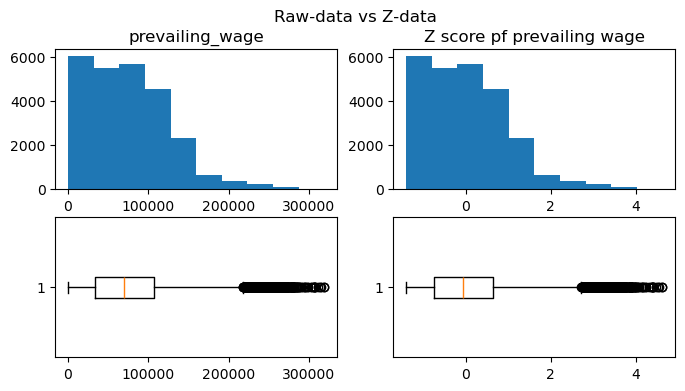

In [19]:
plt.figure(figsize=(8,4))
plt.suptitle('Raw-data vs Z-data')
plt.subplot(2,2,1).hist(visa_df['prevailing_wage'])
plt.title('prevailing_wage')
plt.subplot(2,2,2).hist(z_wage)
plt.title('Z score pf prevailing wage')
plt.subplot(2,2,3).boxplot(visa_df['prevailing_wage'],vert=False)
plt.subplot(2,2,4).boxplot(z_wage,vert=False)


In [ ]:
## StandardScalar

- sklearn

    - preprocessing

        - StandardScalar

In [25]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
visa_df['prevailing_wage']=sc.fit_transform(visa_df[['prevailing_wage']])
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,z_wage
0,EZYV01,Asia,High School,N,N,14513,2007,West,-1.398537,Hour,Y,Denied,-1.398537
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,0.169835,Year,Y,Certified,0.169835
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,0.919079,Year,Y,Denied,0.919079
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,0.169994,Year,Y,Denied,0.169994
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,1.428604,Year,Y,Certified,1.428604
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,0.049924,Year,Y,Certified,0.049924
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,3.876159,Year,Y,Certified,3.876159
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,1.360280,Year,N,Certified,1.360280
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,0.221509,Year,Y,Certified,0.221509


In [26]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
wage_ss=ss.fit_transform(visa_df[['prevailing_wage']])
visa_df['wage_ss']=wage_ss

In [28]:
visa_df[['prevailing_wage']]

,prevailing_wage
0,-1.398537
1,0.169835
2,0.919079
3,0.169994
4,1.428604
...,...
25475,0.049924
25476,3.876159
25477,1.360280
25478,0.221509


In [29]:
visa_df[['prevailing_wage','z_wage']]

,prevailing_wage,z_wage
0,-1.398537,-1.398537
1,0.169835,0.169835
2,0.919079,0.919079
3,0.169994,0.169994
4,1.428604,1.428604
...,...,...
25475,0.049924,0.049924
25476,3.876159,3.876159
25477,1.360280,1.360280
25478,0.221509,0.221509


In [ ]:
visa_df['prevailing_wage']
visa_df['prevailing_wage'].values
visa_df[['prevailing_wage']]

In [30]:
visa_df['prevailing_wage'].values.reshape(-1,1)

array([[-1.39853722],
       [ 0.1698353 ],
       [ 0.91907852],
       ...,
       [ 1.36027953],
       [ 0.22150859],
       [-0.06776315]])

In [34]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
wage_ss=ss.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))
visa_df['wage_ss']=wage_ss
wage_ss

array([[-1.39853722],
       [ 0.1698353 ],
       [ 0.91907852],
       ...,
       [ 1.36027953],
       [ 0.22150859],
       [-0.06776315]])

## MIN-Max Scalar

In [ ]:
# step 1: read the data
# step 2:calculate mean
# step 3: calculate max
# step 4: Nr=step1-step2
# step 5: dr=step3-step4
# step 6: nr/dr
# step 7: visa_df['wage_min_max']=nr/dr


In [51]:
wage_min_max=visa_df['prevailing_wage']


In [52]:
mean=wage_min_max.min()
mean

-1.4097095626210332

In [53]:
maxs=wage_min_max.max()
maxs

4.634192776650989

In [54]:
Nr=wage_min_max-mean
Nr

0        0.011172
1        1.579545
2        2.328788
3        1.579704
4        2.838313
           ...   
25475    1.459634
25476    5.285869
25477    2.769989
25478    1.631218
25479    1.341946
Name: prevailing_wage, Length: 25480, dtype: float64

In [55]:
Dr=maxs-Nr
Dr

0        4.623020
1        3.054648
2        2.305405
3        3.054489
4        1.795879
           ...   
25475    3.174559
25476   -0.651676
25477    1.864204
25478    3.002975
25479    3.292246
Name: prevailing_wage, Length: 25480, dtype: float64

In [56]:
visa_df['wage_min_max']=Nr/Dr
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,z_wage,wage_ss,wage_min_max
0,EZYV01,Asia,High School,N,N,14513,2007,West,-1.398537,Hour,Y,Denied,-1.398537,-1.398537,0.002417
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,0.169835,Year,Y,Certified,0.169835,0.169835,0.517096
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,0.919079,Year,Y,Denied,0.919079,0.919079,1.010143
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,0.169994,Year,Y,Denied,0.169994,0.169994,0.517174
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,1.428604,Year,Y,Certified,1.428604,1.428604,1.580459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,0.049924,Year,Y,Certified,0.049924,0.049924,0.459791
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,3.876159,Year,Y,Certified,3.876159,3.876159,-8.111193
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,1.360280,Year,N,Certified,1.360280,1.360280,1.485883
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,0.221509,Year,Y,Certified,0.221509,0.221509,0.543201


In [50]:
from sklearn.preprocessing import  MinMaxScaler
mms=MinMaxScaler()
mms.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))

array([[0.00184853],
       [0.2613452 ],
       [0.385312  ],
       ...,
       [0.45831136],
       [0.26989486],
       [0.22203311]])